In [1]:
!pip install timm -q

import os
import torch
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn, optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
DATA_DIR = "/kaggle/input/datasets/resvit/venkat-sai-k/Final_Data"  # change this

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "val")
TEST_DIR  = os.path.join(DATA_DIR, "test")

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
])

In [4]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=val_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [5]:
targets = [label for _, label in train_dataset]
class_count = np.bincount(targets)

weights = 1. / class_count
sample_weights = [weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [6]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [7]:
model = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=num_classes)
model.to(device)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2dSame(3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNormAct2d(
          48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNo

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=3e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

In [9]:
def train_model(epochs=30):

    scaler = torch.cuda.amp.GradScaler()
    best_f1 = 0

    for epoch in range(epochs):

        # 🔹 TRAIN
        model.train()
        total_loss, total_samples = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

        train_loss = total_loss / total_samples

        # 🔹 VALIDATION
        model.eval()
        preds_all, labels_all = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)

                preds_all.extend(preds.cpu().numpy())
                labels_all.extend(labels.numpy())

        val_f1 = f1_score(labels_all, preds_all, average='macro')

        scheduler.step()

        # 🔹 SAVE BEST
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_efficientnet_b4.pth")

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    print("✅ Training Complete")

In [10]:
train_model(epochs=30)

/tmp/ipykernel_55/299708095.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/30]
Train Loss: 0.8445
Val F1: 0.8744
Best F1: 0.8744
--------------------------------------------------


/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [2/30]
Train Loss: 0.6305
Val F1: 0.8776
Best F1: 0.8776
--------------------------------------------------


/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch [28/30]
Train Loss: 0.3507
Val F1: 0.9528
Best F1: 0.9528
--------------------------------------------------


/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [29/30]
Train Loss: 0.3509
Val F1: 0.9516
Best F1: 0.9528
--------------------------------------------------


/tmp/ipykernel_55/299708095.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [30/30]
Train Loss: 0.3508
Val F1: 0.9541
Best F1: 0.9541
--------------------------------------------------
✅ Training Complete


In [11]:
model.load_state_dict(torch.load("best_efficientnet_b4.pth", map_location=device))
model.eval()

EfficientNet(
  (conv_stem): Conv2dSame(3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNormAct2d(
          48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNo

In [12]:
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

f1 = f1_score(all_labels, all_preds, average='macro')

print("🔥 TEST F1:", f1)
print(classification_report(all_labels, all_preds, target_names=class_names))

🔥 TEST F1: 0.9505463770252665
                     precision    recall  f1-score   support

           Covid-19       1.00      1.00      1.00       405
             Normal       0.99      0.99      0.99       405
Pneumonia-Bacterial       0.93      0.88      0.91       405
    Pneumonia-Viral       0.89      0.93      0.91       405

           accuracy                           0.95      1620
          macro avg       0.95      0.95      0.95      1620
       weighted avg       0.95      0.95      0.95      1620



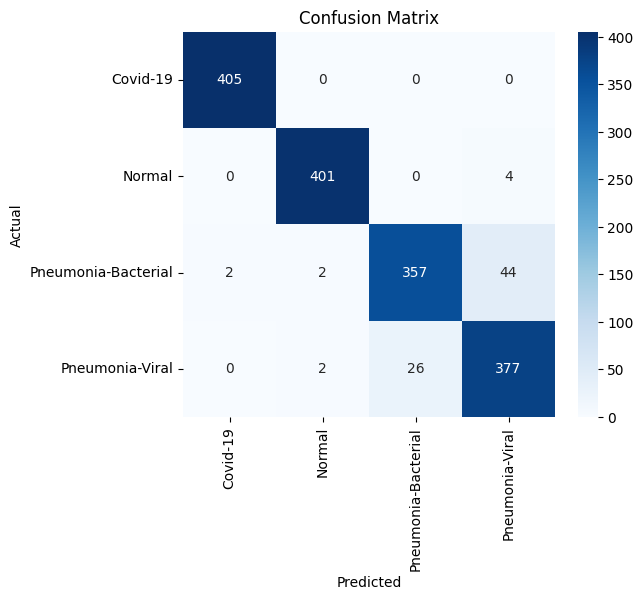

In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()